In [1]:
import matplotlib.pyplot as plt
import polars as pl

import parcels

/tmp/ipykernel_1733308/3671891571.py:4: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
df = [parcels.read_particlefile(f"Simulations/Simulation_Satellite_kN_{k_N}.parquet") for k_N in [0.01, 0.001, 0.000129]]

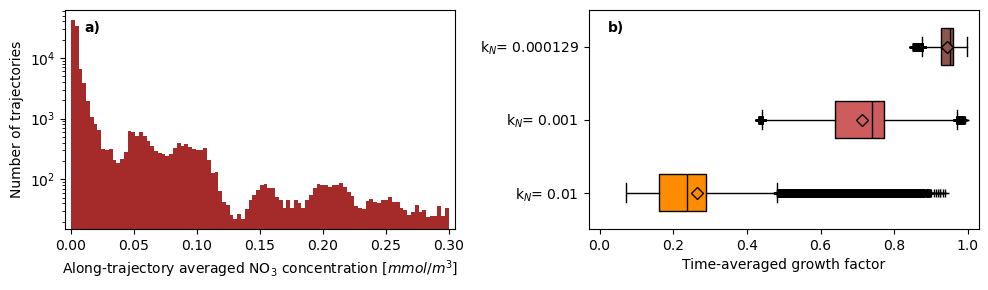

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

no3_timemean = df[1].group_by('particle_id').agg(pl.col('nitrogen').mean())['nitrogen'].to_numpy()
ax[0].hist(no3_timemean, bins=100, range=(0, 0.3), log=True, color='brown')
ax[0].set_xlabel('Along-trajectory averaged NO$_3$ concentration [$mmol / m^3$]')
ax[0].set_ylabel('Number of trajectories')
ax[0].set_xlim(-0.005, 0.305)

colors = ['darkorange', 'indianred', 'tab:brown']
names = ['k$_N$= 0.01', 'k$_N$= 0.001', 'k$_N$= 0.000129']

for i, dframe in enumerate(df):
    _, data = dframe.group_by('particle_id').agg(pl.col('lim_no3').mean())
    ax[1].boxplot(
        data,
        positions=[i],
        widths=0.5,
        patch_artist=True,
        orientation='horizontal',
        boxprops=dict(facecolor=colors[i]),
        medianprops=dict(color='black'),
        showmeans=True,
        meanprops = dict(marker='D',markeredgecolor='black', markerfacecolor=colors[i]),
        sym='+'
    )

#Assiging labels
for i, name in enumerate(names):
    ax[1].plot([], [], color=colors[i], label=name)
ax[1].set_yticks(range(len(names)))
ax[1].set_yticklabels(names)
ax[1].set_xlabel('Time-averaged growth factor')
ax[1].set_xlim(-0.03,1.03)

for i, label in enumerate(['a)', 'b)']):
    ax[i].text(0.05, 0.95, label, transform=ax[i].transAxes,
               fontsize=10, fontweight='bold', va='top')

plt.tight_layout()
fig.savefig('Figures/Figure3.pdf', bbox_inches='tight', dpi=300)
plt.show()